In [1]:
# make quasistatic compression code

# make ke calculation functions

# make temperature calculation function (drift / no-drift)

# make temperature setting function (drift / no-drift)

# make nvt compression code

# make pe an array in state

# NeighborList (cached cell-list) -1 padding causes issues
#   does not initially build the list
#   -1 padding causes issues

# fill out the pe array when computing forces (would this be slower?)

# make h5 saving tool
#   initial state
#   final state
#   trajectory
#       save only specific variables (i.e. set variables, only clump com data)
#       logarithmic saving
#   overwrite any variable with the most recent occurance

# only roll out variables that need to be saved

In [2]:
import os
import numpy as np
import jaxdem as jd
import jax
import jax.numpy as jnp
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

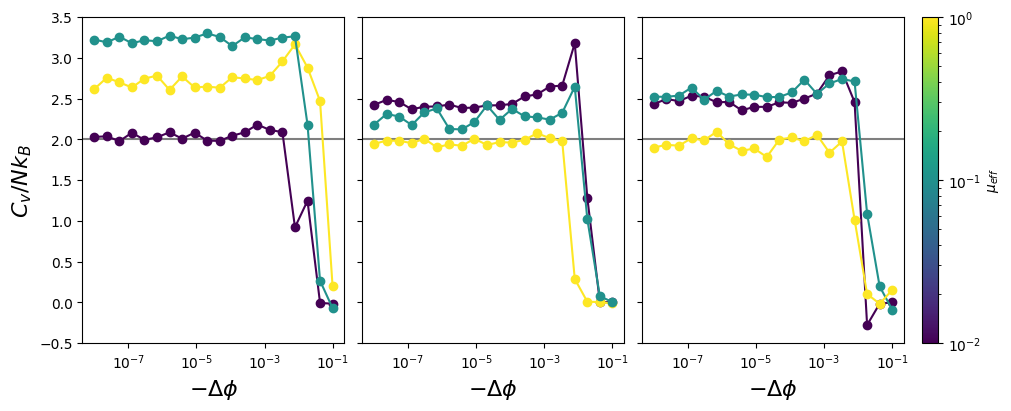

In [5]:
root = '/home/mmccraw/dev/data/01-01-26/specific-heat/dynamics/'

N = 50
dim = 2

cmap = plt.cm.viridis
mu_norm = LogNorm(vmin=1e-2, vmax=1)

fig, ax = plt.subplots(1, 3, figsize=(10, 4), constrained_layout=True, sharey=True, sharex=True)

for particle_type in os.listdir(root):
    cv = []
    delta_phi = []

    _, mu, _, alpha = particle_type.split('-')
    mu = float(mu)
    alpha = float(alpha)

    particle_root = os.path.join(root, particle_type)
    for dphi_name in os.listdir(particle_root):
        file_path = os.path.join(particle_root, dphi_name, 'data.h5')
        with h5py.File(file_path, 'r') as f:
            T = f['T'][()]
            ke_r = f['ke_r'][()]
            ke_t = f['ke_t'][()]
            pe = f['pe'][()]

        te = pe + ke_r + ke_t

        _cv, _ = np.polyfit(np.mean(T, axis=0), np.mean(te, axis=0), 1)
        _cv /= N

        cv.append(_cv)
        delta_phi.append(float(dphi_name.split('dphi-')[-1]))

    cv = np.array(cv)[np.argsort(delta_phi)]
    delta_phi = np.array(delta_phi)[np.argsort(delta_phi)]

    idx = int(2 * (alpha - 1))
    ax[idx].plot(delta_phi, cv, c=cmap(mu_norm(mu)), marker='o')
for a in ax:
    a.set_xscale('log')
    a.set_ylim(-0.5, 3.5)
    a.set_xlabel(r'$-\Delta \phi$', fontsize=16)
    a.axhline(2.0, zorder=0, c='k', alpha=0.5)
ax[0].set_ylabel(r'$C_v / N k_B$', fontsize=16)


sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array([1e-2, 1e-1, 1e0])
cbar = plt.colorbar(sm, ax=ax[-1], label=r'$\mu_{eff}$')
